# Climate and Hazard Features

**Purpose.** Examine the definition, provenance, transformation, grain, joined
completeness, distribution, outliers, redundancy, temporal alignment, retention
decision, and infographic use of the domain features.

This notebook is a diagnostic consumer of the `feature.*` semantic marts. Database
construction owns every feature transformation.

## Setup and authoritative feature definitions

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
while not (ROOT / "data" / "quoll.duckdb").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
con = duckdb.connect(str(ROOT / "data" / "quoll.duckdb"), read_only=True)
FEATURE_TABLES = ['county_climate_monthly', 'county_risk']
EXCLUDED_CATALOG_FEATURES = []
TABLE_NAMES = ", ".join("?" for _ in FEATURE_TABLES)

catalog = con.execute(
    f"SELECT * FROM feature.catalog "
    f"WHERE feature_table IN ({TABLE_NAMES}) "
    f"OR (feature_table IS NULL AND lower(category) = lower(?))"
    f"ORDER BY retained DESC, feature_table, feature_name",
    [*FEATURE_TABLES, 'Climate and Hazard'],
).df()
catalog = catalog.loc[
    ~catalog["feature_name"].isin(EXCLUDED_CATALOG_FEATURES)
].copy()
display(catalog)

,geographic_grain,retained,exclusion_reason,feature_table,feature_name,category,definition,unit,source_tables,transformation,temporal_grain,infographic_use
0,county,True,None,county_climate_monthly,avg_temperature_f,Climate and hazard,Monthly county average temperature.,degrees Fahrenheit,mart.ncei_county_weather_monthly,NCEI parameter pivot.,monthly,Feature comparison: Temperature
1,county,True,None,county_climate_monthly,extreme_event_count,Climate and hazard,Combined qualifying FEMA and billion-dollar NO...,county-events,mart.fema_disaster_declarations; mart.noaa_sto...,Sum of FEMA and NOAA qualifying county-event c...,monthly,Feature comparison: Combined Extreme Event Count
2,county,True,None,county_climate_monthly,precipitation_inches,Climate and hazard,Monthly county precipitation.,inches,mart.ncei_county_weather_monthly,NCEI parameter pivot.,monthly,Feature comparison: Precipitation
3,county,False,Replaced by combined extreme_event_count.,county_climate_monthly,fema_event_count,Climate and hazard,Qualifying FEMA county-events beginning in the...,county-events,mart.fema_disaster_declarations,Distinct disaster/county/start records after i...,monthly,Event definition and Climate Playbook
4,county,False,Replaced by combined extreme_event_count.,county_climate_monthly,noaa_extreme_event_count,Climate and hazard,NOAA county-events beginning in the month with...,county-events,mart.noaa_storm_events,Distinct NOAA event/county/start records above...,monthly,Event definition and Climate Playbook
5,county,False,Removed from county-relative PPSF model features.,county_risk,community_resilience_score,Climate and hazard,NRI community resilience score.,score,mart.nri_county_risk,Numeric NRI RESL score.,snapshot,Risk context
6,county,False,Removed from county-relative PPSF model features.,county_risk,expected_annual_loss_score,Climate and hazard,NRI expected annual loss score.,score,mart.nri_county_risk,Numeric NRI EAL score.,snapshot,Risk context
7,county,False,"Used to define the modeling group, not as a pr...",county_risk,risk_rating,Climate and hazard,FEMA National Risk Index categorical risk rating.,category,mart.nri_county_risk,Canonical NRI rating label.,snapshot,Risk-group comparisons
8,county,False,Removed from county-relative PPSF model features.,county_risk,risk_score,Climate and hazard,FEMA National Risk Index composite risk score.,score,mart.nri_county_risk,Numeric NRI score.,snapshot,Risk map and grouping
9,county,False,Removed from county-relative PPSF model features.,county_risk,social_vulnerability_score,Climate and hazard,NRI social vulnerability score.,score,mart.nri_county_risk,Numeric NRI SOVI score.,snapshot,Risk context


The catalog above is the answer key for definition, unit, source, transformation,
grain, retention/exclusion, and infographic use. The remaining sections test whether
the built data match those definitions.

## Geographic and temporal grain

In [2]:
inventory_rows = []
for table in FEATURE_TABLES:
    columns = con.execute(f"DESCRIBE feature.{table}").df()["column_name"].tolist()
    time_column = next((c for c in ["year", "climate_month", "housing_month"] if c in columns), None)
    time_sql = (
        f"min({time_column}) AS min_time, max({time_column}) AS max_time, "
        f"count(DISTINCT {time_column}) AS periods"
        if time_column else
        "NULL AS min_time, NULL AS max_time, NULL AS periods"
    )
    row = con.execute(
        f"SELECT count(*) AS rows, count(DISTINCT fips) AS counties, {time_sql} "
        f"FROM feature.{table}"
    ).df()
    row.insert(0, "feature_table", table)
    inventory_rows.append(row)
inventory = pd.concat(inventory_rows, ignore_index=True)
display(inventory)

,feature_table,rows,counties,min_time,max_time,periods
0,county_climate_monthly,240708,3323,1953,2026,74
1,county_risk,3232,3232,<NA>,<NA>,<NA>


## Completeness after joins

In [3]:
completeness_frames = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    has_year = "year" in schema["column_name"].tolist()
    numeric_columns = schema.loc[
        schema["column_type"].str.contains(
            "DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT|HUGEINT", case=False, regex=True
        ),
        "column_name",
    ].tolist()
    feature_columns = [
        column for column in numeric_columns
        if column not in {"year", "month"} and not column.endswith("_count")
    ]
    row_count = con.execute(f"SELECT count(*) FROM feature.{table}").fetchone()[0]
    rows = []
    for column in feature_columns:
        if has_year:
            present, first_year, last_year = con.execute(
                f'SELECT count("{column}"), '
                f'min(year) FILTER (WHERE "{column}" IS NOT NULL), '
                f'max(year) FILTER (WHERE "{column}" IS NOT NULL) '
                f"FROM feature.{table}"
            ).fetchone()
            in_scope_rows = con.execute(
                f"SELECT count(*) FROM feature.{table} "
                f"WHERE year BETWEEN ? AND ?",
                [first_year, last_year],
            ).fetchone()[0] if first_year is not None and last_year is not None else 0
        else:
            present = con.execute(
                f'SELECT count("{column}") FROM feature.{table}'
            ).fetchone()[0]
            first_year = last_year = None
            in_scope_rows = row_count
        rows.append({
            "feature_table": table, "feature_name": column,
            "non_null_rows": present, "total_rows": row_count,
            "global_complete_pct": present / row_count * 100 if row_count else np.nan,
            "first_observed_year": first_year,
            "last_observed_year": last_year,
            "in_scope_rows": in_scope_rows,
            "in_scope_complete_pct": (
                present / in_scope_rows * 100 if in_scope_rows else np.nan
            ),
        })
    completeness_frames.append(pd.DataFrame(rows))
completeness = pd.concat(completeness_frames, ignore_index=True)
display(completeness.sort_values(["feature_table", "global_complete_pct"]))

C:\Users\kenny\AppData\Local\Temp\ipykernel_5176\763975266.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  completeness = pd.concat(completeness_frames, ignore_index=True)


,feature_table,feature_name,non_null_rows,total_rows,global_complete_pct,first_observed_year,last_observed_year,in_scope_rows,in_scope_complete_pct
4,county_climate_monthly,avg_temperature_anomaly_f,0,240708,0.000000,NaN,NaN,0,NaN
5,county_climate_monthly,precipitation_anomaly_inches,0,240708,0.000000,NaN,NaN,0,NaN
0,county_climate_monthly,avg_temperature_f,192360,240708,79.914253,2016.0,2025.0,197733,97.282699
1,county_climate_monthly,min_temperature_f,192360,240708,79.914253,2016.0,2025.0,197733,97.282699
2,county_climate_monthly,max_temperature_f,192360,240708,79.914253,2016.0,2025.0,197733,97.282699
3,county_climate_monthly,precipitation_inches,192360,240708,79.914253,2016.0,2025.0,197733,97.282699
6,county_climate_monthly,noaa_extreme_damage_usd,240708,240708,100.000000,1953.0,2026.0,240708,100.000000
7,county_risk,risk_score,3144,3232,97.277228,NaN,NaN,3232,97.277228
9,county_risk,social_vulnerability_score,3144,3232,97.277228,NaN,NaN,3232,97.277228
10,county_risk,community_resilience_score,3144,3232,97.277228,NaN,NaN,3232,97.277228


## Distributions, outliers, and implausible values

In [4]:
frames = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric_columns = schema.loc[
        schema["column_type"].str.contains(
            "DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT|HUGEINT", case=False, regex=True
        ),
        "column_name",
    ].tolist()
    numeric_columns = [
        c for c in numeric_columns
        if c not in {"year", "month"} and not c.endswith("_count")
    ]
    if not numeric_columns:
        continue
    quoted = ", ".join(f'"{column}"' for column in numeric_columns)
    frame = con.execute(f"SELECT {quoted} FROM feature.{table}").df()
    description = frame.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.reset_index(
        names="feature_name"
    )
    description.insert(0, "feature_table", table)
    q1 = frame.quantile(0.25)
    q3 = frame.quantile(0.75)
    iqr = q3 - q1
    outlier_counts = ((frame.lt(q1 - 1.5 * iqr)) | (frame.gt(q3 + 1.5 * iqr))).sum()
    description["iqr_outlier_count"] = description["feature_name"].map(outlier_counts)
    description["review_flag"] = np.where(
        (description["min"] < 0)
        & description["feature_name"].str.contains(
            "income|wage|population|price|value|precipitation|score", case=False
        ),
        "negative value requires review",
        np.where(description["iqr_outlier_count"] > 0, "distribution has IQR outliers", "none"),
    )
    frames.append(description)
distributions = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
display(distributions)

,feature_table,feature_name,count,mean,std,min,1%,25%,50%,75%,99%,max,iqr_outlier_count,review_flag
0,county_climate_monthly,avg_temperature_f,192360.0,54.105368,1.797427e+01,-7.900000,13.000000,40.500000,56.000000,69.100000,83.400000,9.810000e+01,10,distribution has IQR outliers
1,county_climate_monthly,min_temperature_f,192360.0,43.240940,1.745134e+01,-17.100000,3.400000,30.200000,44.200000,57.400000,73.900000,8.400000e+01,54,distribution has IQR outliers
2,county_climate_monthly,max_temperature_f,192360.0,64.963494,1.875745e+01,1.400000,22.200000,50.900000,68.000000,80.700000,94.000000,1.122000e+02,10,distribution has IQR outliers
3,county_climate_monthly,precipitation_inches,192360.0,3.383110,2.527853e+00,0.000000,0.050000,1.510000,2.930000,4.680000,11.550000,4.045000e+01,4769,distribution has IQR outliers
4,county_climate_monthly,avg_temperature_anomaly_f,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
5,county_climate_monthly,precipitation_anomaly_inches,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
6,county_climate_monthly,noaa_extreme_damage_usd,240708.0,502020.165512,5.806238e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.700000e+10,40,distribution has IQR outliers
7,county_risk,risk_score,3144.0,50.015903,2.887210e+01,0.031807,1.031489,25.023855,50.015903,75.007952,99.000318,1.000000e+02,0,none
8,county_risk,expected_annual_loss_score,3232.0,50.015470,2.887198e+01,0.030941,1.030631,25.023205,50.015470,75.007735,99.000309,1.000000e+02,0,none
9,county_risk,social_vulnerability_score,3144.0,50.623193,2.799764e+01,10.623410,10.623410,25.047710,50.031807,75.031807,99.000318,1.000000e+02,0,none


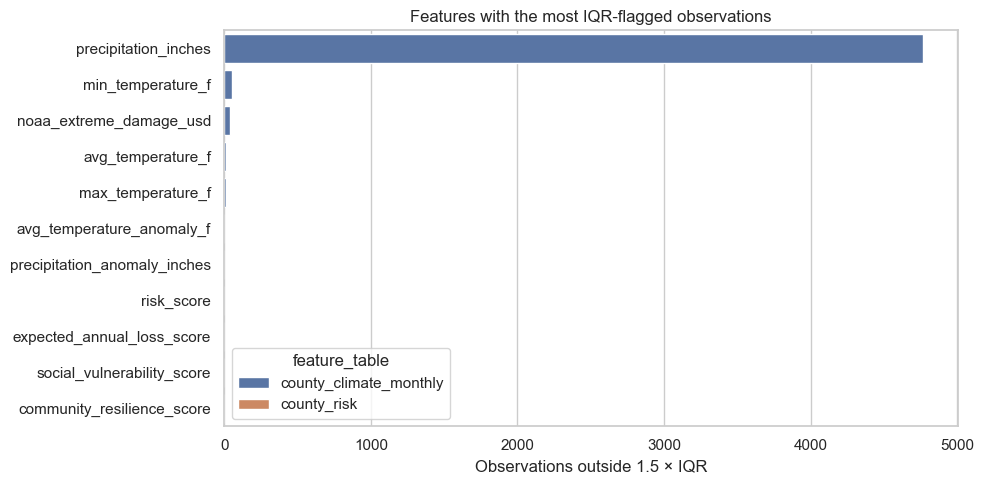

In [5]:
plot_data = distributions.sort_values("iqr_outlier_count", ascending=False).head(12)
if not plot_data.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=plot_data, y="feature_name", x="iqr_outlier_count", hue="feature_table", ax=ax)
    ax.set_title("Features with the most IQR-flagged observations")
    ax.set_xlabel("Observations outside 1.5 × IQR")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## Redundancy among related features

In [6]:
correlation_frames = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric_columns = schema.loc[
        schema["column_type"].str.contains("DOUBLE|FLOAT|DECIMAL", case=False, regex=True),
        "column_name",
    ].tolist()
    if len(numeric_columns) < 2:
        continue
    quoted = ", ".join(f'"{column}"' for column in numeric_columns)
    frame = con.execute(f"SELECT {quoted} FROM feature.{table}").df()
    corr = frame.corr(min_periods=100)
    pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .rename("correlation")
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    )
    pairs.insert(0, "feature_table", table)
    correlation_frames.append(pairs)
correlations = pd.concat(correlation_frames, ignore_index=True) if correlation_frames else pd.DataFrame()
if not correlations.empty:
    correlations["absolute_correlation"] = correlations["correlation"].abs()
    display(correlations.sort_values("absolute_correlation", ascending=False).head(30))
else:
    display(pd.DataFrame({"result": ["Fewer than two continuous features were available."]}))

,feature_table,feature_a,feature_b,correlation,absolute_correlation
1,county_climate_monthly,avg_temperature_f,max_temperature_f,0.993208,0.993208
0,county_climate_monthly,avg_temperature_f,min_temperature_f,0.992143,0.992143
4,county_climate_monthly,min_temperature_f,max_temperature_f,0.970857,0.970857
10,county_risk,risk_score,expected_annual_loss_score,0.963294,0.963294
15,county_risk,social_vulnerability_score,community_resilience_score,-0.493893,0.493893
5,county_climate_monthly,min_temperature_f,precipitation_inches,0.353399,0.353399
14,county_risk,expected_annual_loss_score,community_resilience_score,0.346960,0.346960
2,county_climate_monthly,avg_temperature_f,precipitation_inches,0.298196,0.298196
7,county_climate_monthly,max_temperature_f,precipitation_inches,0.242624,0.242624
13,county_risk,expected_annual_loss_score,social_vulnerability_score,-0.224202,0.224202


## Temporal alignment

In [7]:
alignment_frames = []
for table in FEATURE_TABLES:
    columns = con.execute(f"DESCRIBE feature.{table}").df()["column_name"].tolist()
    time_column = next((c for c in ["year", "climate_month", "housing_month"] if c in columns), None)
    flags = [c for c in columns if c.startswith("has_")]
    if time_column and flags:
        aggregates = ", ".join(
            f'avg(cast("{flag}" AS INTEGER)) * 100 AS "{flag}_pct"' for flag in flags
        )
        alignment = con.execute(
            f"SELECT {time_column}, count(DISTINCT fips) AS counties, {aggregates} "
            f"FROM feature.{table} GROUP BY {time_column} ORDER BY {time_column}"
        ).df()
        alignment.insert(0, "feature_table", table)
        alignment_frames.append(alignment)
    elif time_column:
        alignment = con.execute(
            f"SELECT {time_column}, count(DISTINCT fips) AS counties "
            f"FROM feature.{table} GROUP BY {time_column} ORDER BY {time_column}"
        ).df()
        alignment.insert(0, "feature_table", table)
        alignment_frames.append(alignment)
alignment = pd.concat(alignment_frames, ignore_index=True) if alignment_frames else pd.DataFrame()
display(alignment)

,feature_table,year,counties,has_ncei_weather_pct
0,county_climate_monthly,1953,10,0.000000
1,county_climate_monthly,1954,16,0.000000
2,county_climate_monthly,1955,16,0.000000
3,county_climate_monthly,1956,13,0.000000
4,county_climate_monthly,1957,15,0.000000
5,county_climate_monthly,1958,7,0.000000
6,county_climate_monthly,1959,6,0.000000
7,county_climate_monthly,1960,10,0.000000
8,county_climate_monthly,1961,12,0.000000
9,county_climate_monthly,1962,18,0.000000


## Retention and infographic use

Retention is decided in `feature.catalog`, not from visual inspection in this
notebook. A feature is retained when its definition is interpretable, its unit and
grain are stable, its completeness is adequate for its intended comparison, and it
does not duplicate the outcome or a stronger related measure. The `infographic_use`
and `exclusion_reason` catalog fields record the current decision.

In [8]:
display(catalog[[
    "feature_name", "retained", "exclusion_reason", "infographic_use",
    "source_tables", "transformation"
]])
con.close()

,feature_name,retained,exclusion_reason,infographic_use,source_tables,transformation
0,avg_temperature_f,True,None,Feature comparison: Temperature,mart.ncei_county_weather_monthly,NCEI parameter pivot.
1,extreme_event_count,True,None,Feature comparison: Combined Extreme Event Count,mart.fema_disaster_declarations; mart.noaa_sto...,Sum of FEMA and NOAA qualifying county-event c...
2,precipitation_inches,True,None,Feature comparison: Precipitation,mart.ncei_county_weather_monthly,NCEI parameter pivot.
3,fema_event_count,False,Replaced by combined extreme_event_count.,Event definition and Climate Playbook,mart.fema_disaster_declarations,Distinct disaster/county/start records after i...
4,noaa_extreme_event_count,False,Replaced by combined extreme_event_count.,Event definition and Climate Playbook,mart.noaa_storm_events,Distinct NOAA event/county/start records above...
5,community_resilience_score,False,Removed from county-relative PPSF model features.,Risk context,mart.nri_county_risk,Numeric NRI RESL score.
6,expected_annual_loss_score,False,Removed from county-relative PPSF model features.,Risk context,mart.nri_county_risk,Numeric NRI EAL score.
7,risk_rating,False,"Used to define the modeling group, not as a pr...",Risk-group comparisons,mart.nri_county_risk,Canonical NRI rating label.
8,risk_score,False,Removed from county-relative PPSF model features.,Risk map and grouping,mart.nri_county_risk,Numeric NRI score.
9,social_vulnerability_score,False,Removed from county-relative PPSF model features.,Risk context,mart.nri_county_risk,Numeric NRI SOVI score.
